Main code importing the exsiting data and preforming regression

First imporing packages

In [15]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import curve_fit
from pathlib import Path
import os


Changing positiopnes and importing files

In [16]:
current_dir = os.getcwd()
print(f"Current: {current_dir}")

parent_dir = os.path.dirname(current_dir)
print(f"Parent: {parent_dir}")

data_stock_SSP1 = os.path.join(parent_dir, "data", "processed_baseline", "stock_SSP1.csv")



Current: c:\Users\mathi\Documents\2. Skole\MFA 2 -studas\master\electrolysers\scenarios
Parent: c:\Users\mathi\Documents\2. Skole\MFA 2 -studas\master\electrolysers


Defining functions

In [17]:
def logistic(x:np.ndarray,ti:float,tau:float,C0:float,C1:float) -> np.ndarray:
    """
    General logistic function.
    Arguments:
    - x: np.ndarray of observation points (time)
    - ti: inflection time
    - tau: transition time coefficient
    - C0: start value
    - C1: end value

    Returns:
    - np.ndarray with len(x) number of points
    """
    return (C1 - C0)/(1 + np.exp(-(x - ti) / tau)) + C0  

Traeting data

In [18]:
stock_SSP1 = pd.read_csv(data_stock_SSP1).groupby("Year")["Value"].sum()
df_stock_SSP1 = pd.read_csv(data_stock_SSP1)

stock_SSP1 = df_stock_SSP1.groupby("Year")["Value"].sum()

# Remove the row with index 'Unnamed: 24' if it exists
stock_SSP1 = stock_SSP1[stock_SSP1.index != 'Unnamed: 24']

# Convert index (Year) to int
stock_SSP1.index = stock_SSP1.index.astype(int)

# Then filter out 2025 to 2050
stock_SSP1_2050 = stock_SSP1.loc[2025:2050]

# Convert to arrays
years = stock_SSP1_2050.index.to_numpy()

# Convert to arrays
values_SSP1_2050 = stock_SSP1_2050.to_numpy()

Plot data

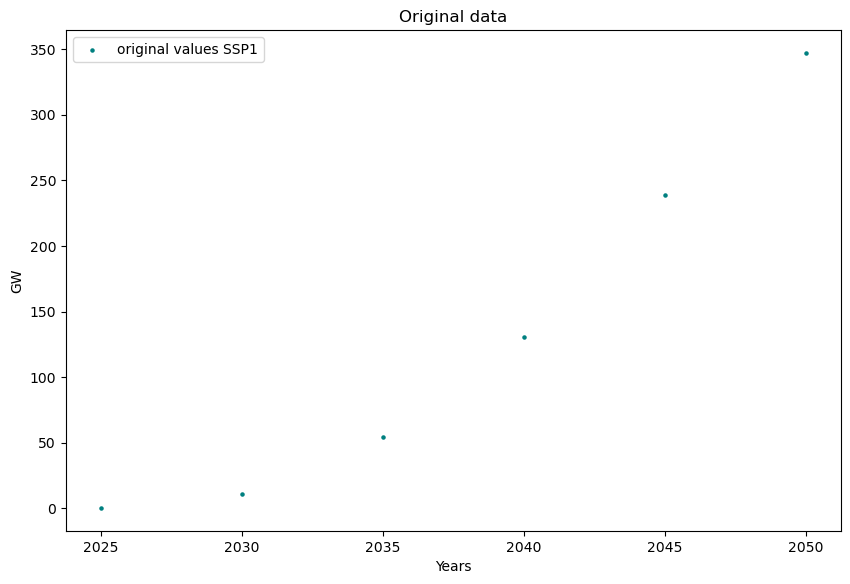

In [19]:
#%% Plot the original data
plt.figure(figsize=(10,6.5))
plt.scatter(years, values_SSP1_2050,  color= 'teal', s=5, label = f'original values SSP1', zorder = 3)  # Add dots for each data point
plt.legend(loc = 'best')
plt.xlabel('Years')
plt.ylabel('GW')
plt.title('Original data')
plt.show()

Adding historic data

In [23]:
historic_data = [14.12, 46.36, 102.87, 162.19, 289.46]
historic_data = np.array(historic_data) / 1000
combined_SSP1 = np.concatenate((historic_data, values_SSP1_2050))

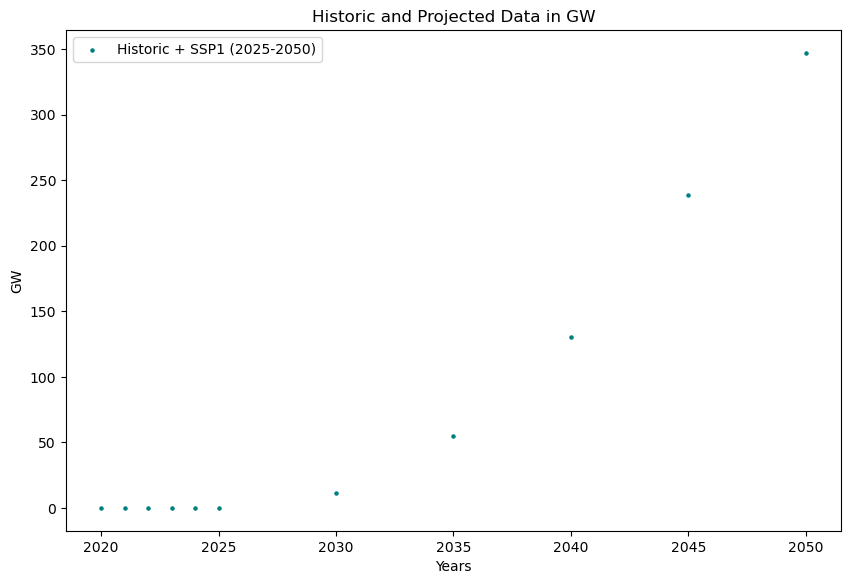

In [26]:
# Create combined years array for historic + future data
historic_years = np.array([2020, 2021, 2022, 2023, 2024])  # Assuming these are the years for the historic data
combined_years = np.concatenate((historic_years, years))

# Plot historic and future data
plt.figure(figsize=(10, 6.5))
plt.scatter(combined_years, combined_SSP1, color='teal', s=5, label='Historic + SSP1 (2025-2050)', zorder=3)
plt.legend(loc='best')
plt.xlabel('Years')
plt.ylabel('GW')
plt.title('Historic and Projected Data in GW')
plt.show()

Optimized parameters:
  Inflection time (ti): 2044.29
  Transition time (tau): 4.82
  Start value (C0): -5.595280
  End value (C1): 453.96


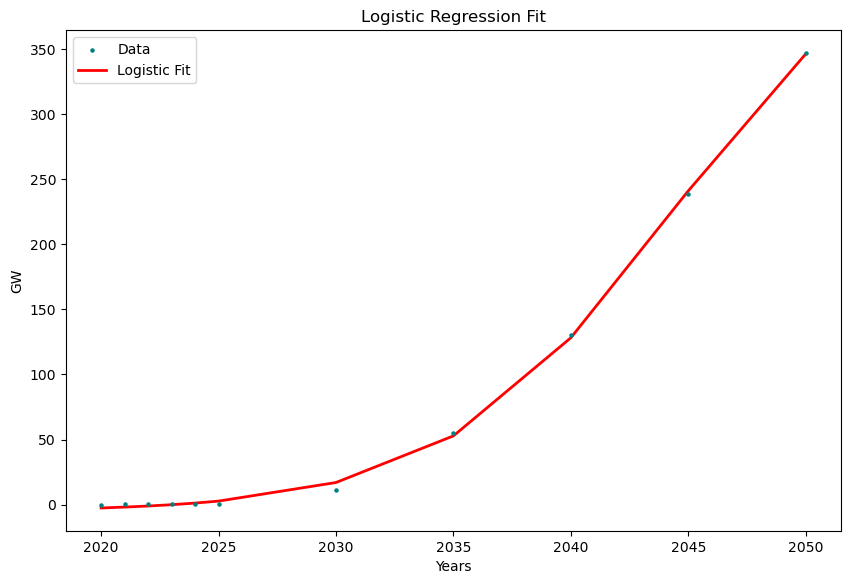

In [25]:
# Initial parameter guesses
p0 = [2035, 5, 0.01, 350]

# Perform curve fitting
popt, pcov = curve_fit(logistic, combined_years, combined_SSP1, p0=p0, maxfev=10000)

# Extract optimized parameters
ti_opt, tau_opt, C0_opt, C1_opt = popt

print(f"Optimized parameters:")
print(f"  Inflection time (ti): {ti_opt:.2f}")
print(f"  Transition time (tau): {tau_opt:.2f}")
print(f"  Start value (C0): {C0_opt:.6f}")
print(f"  End value (C1): {C1_opt:.2f}")

# Calculate fitted values
fitted_values = logistic(combined_years, *popt)

# Plot original and fitted data
plt.figure(figsize=(10, 6.5))
plt.scatter(combined_years, combined_SSP1, color='teal', s=5, label='Data', zorder=3)
plt.plot(combined_years, fitted_values, color='red', linewidth=2, label='Logistic Fit')
plt.legend(loc='best')
plt.xlabel('Years')
plt.ylabel('GW')
plt.title('Logistic Regression Fit')
plt.show()

In [1]:
print("test")

test
